# Classification Model Comparison
Predicts CV acceptance/rejection from `matched_score`, comparing 3 models across 3 cosine-similarity feature sets.

In [1]:
# If running locally, utils.py just needs to sit in the same folder as this notebook.
import sys, os

RUNNING_IN_COLAB = 'google.colab' in str(get_ipython())

if RUNNING_IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/project/cv screening'
    os.makedirs(PROJECT_DIR, exist_ok=True)
    sys.path.append(PROJECT_DIR)
else:
    PROJECT_DIR = '.'

DATA_DIR = os.path.join(PROJECT_DIR, 'data')
os.makedirs(DATA_DIR, exist_ok=True)
print(f"PROJECT_DIR = {PROJECT_DIR}")
print(f"DATA_DIR    = {DATA_DIR}")

Mounted at /content/drive
PROJECT_DIR = /content/drive/MyDrive/project/cv screening
DATA_DIR    = /content/drive/MyDrive/project/cv screening/data


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

THRESHOLD = 0.60
TEST_SIZE = 0.15
RANDOM_STATE = 42

## Load data & build target

In [3]:
df = pd.read_csv(f'{DATA_DIR}/ml_ready_dataset.csv')

display(df.head())


,job_position_name,matched_score,Cosine_TFIDF,Cosine_Semantic,Cosine_Hybrid,Cosine_Objective_Fit,Effective_Experience_Years,Semantic_x_Experience,flag_entry_level,Processed_CV,Processed_JD,Experience_Penalty
0,Senior Software Engineer,0.850000,0.577747,0.653809,0.613432,0.534812,6.7,4.380519,True,coca cola big data analyst yrs technical suppo...,senior software engineer technical support tro...,5.7
1,Machine Learning (ML) Engineer,0.750000,0.820796,0.775606,0.719944,0.565635,6.8,5.274123,False,bib consultancy business analyst yrs machine l...,machine learning ml engineer machine learn lea...,1.8
2,"Executive/ Senior Executive- Trade Marketing, ...",0.416667,0.507412,0.741084,0.668831,0.480551,8.1,6.002783,False,axis bank limit software developer machine lea...,executive senior executive trade marketing hyg...,5.1
3,Business Development Executive,0.760000,0.227940,0.623147,0.561918,0.464301,13.8,8.599431,True,accountant yrs account receivable clerk yrs mo...,business development executive type skill ielt...,12.8
4,Senior iOS Engineer,0.650000,0.436036,0.693200,0.629025,0.407535,18.5,12.824193,False,staff accountant yrs senior accountant yrs tax...,senior io engineer ios ios app developer ios a...,14.5


In [4]:
df['flag_entry_level'] = df['flag_entry_level'].fillna(False).astype(int)
df['CV_Accepted'] = np.where(df['matched_score'] >= THRESHOLD, 1, 0)

print(df['CV_Accepted'].value_counts(normalize=True).rename('share'))

CV_Accepted
1    0.729747
0    0.270253
Name: share, dtype: float64


## Train/test split (grouped by candidate)

In [5]:
# Instantiate the grouped splitter to ensure a candidate's CV ,doesn't bleed across both the training and testing sets.
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)


train_idx, test_idx = next(splitter.split(df, groups=df['job_position_name']))

# Create the final Train and Test DataFrames using the indices
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

# Extract the target variable arrays
y_train = train_df['CV_Accepted'].values
y_test = test_df['CV_Accepted'].values

# Output the final split sizes for verification
print(f"Training Set Size: {len(train_df):,}")
print(f"Testing Set Size:  {len(test_df):,}")

Training Set Size: 7,692
Testing Set Size:  1,677


In [6]:

ols = LinearRegression().fit(train_df[['Cosine_Semantic', 'Cosine_TFIDF']], train_df['matched_score'])
for d in (train_df, test_df):
    d['Cosine_Hybrid'] = ols.predict(d[['Cosine_Semantic', 'Cosine_TFIDF']])

## Feature sets & models

In [7]:
meta_cols = [
    'Effective_Experience_Years',
    'Cosine_Objective_Fit',
    'flag_entry_level'  ,
    'Experience_Penalty'
]

feature_sets = {
    'TF-IDF':   ['Cosine_TFIDF'] + meta_cols,
    'Semantic': ['Cosine_Semantic'] + meta_cols,
    'Hybrid':   ['Cosine_Hybrid'] + meta_cols ,
    'All Text Features': ['Cosine_TFIDF', 'Cosine_Semantic'] + meta_cols

}

# Apply Feature Scaling (CRITICAL for Logistic Regression & SVC)
X_train_scaled_sets = {}
X_test_scaled_sets = {}

for fname, cols in feature_sets.items():
    scaler = StandardScaler()
    # Fit ONLY on the training data to prevent leakage, then transform both
    X_train_scaled_sets[fname] = scaler.fit_transform(train_df[cols])
    X_test_scaled_sets[fname] = scaler.transform(test_df[cols])


models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20,
                                             class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'SVC (RBF)': SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE),
}

## Train & evaluate every combination

In [8]:
results = []
fitted_artifacts = {}
roc_data = {}

for fname in feature_sets.keys():
    X_train_scaled = X_train_scaled_sets[fname]
    X_test_scaled = X_test_scaled_sets[fname]

    for mname, model_template in models.items():
        model = clone(model_template)

        # Train
        model.fit(X_train_scaled, y_train)

        # Predict Classes & Probabilities (Fixed missing predict_proba)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]

        # Calculate Metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        auc = roc_auc_score(y_test, y_proba)

        # Calculate ROC coordinates
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_data[(fname, mname)] = (fpr, tpr)

        # Store results safely
        results.append({'Feature Set': fname, 'Model': mname, 'Accuracy': acc, 'F1-Score': f1, 'ROC-AUC': auc})
        fitted_artifacts[(fname, mname)] = (y_pred, y_proba, model)



## Summary report

In [9]:
results_df = pd.DataFrame(results)
display(results_df.sort_values('F1-Score', ascending=False).round(4))


,Feature Set,Model,Accuracy,F1-Score,ROC-AUC
3,Semantic,Logistic Regression,0.7585,0.7142,0.8121
4,Semantic,Random Forest,0.7496,0.7032,0.7882
5,Semantic,SVC (RBF),0.7406,0.6974,0.7830
6,Hybrid,Logistic Regression,0.7573,0.6942,0.7542
8,Hybrid,SVC (RBF),0.7478,0.6919,0.7230
7,Hybrid,Random Forest,0.7543,0.6898,0.7355
0,TF-IDF,Logistic Regression,0.6219,0.5568,0.6187
1,TF-IDF,Random Forest,0.5790,0.5238,0.5411
2,TF-IDF,SVC (RBF),0.5951,0.5067,0.5040


## ROC curves

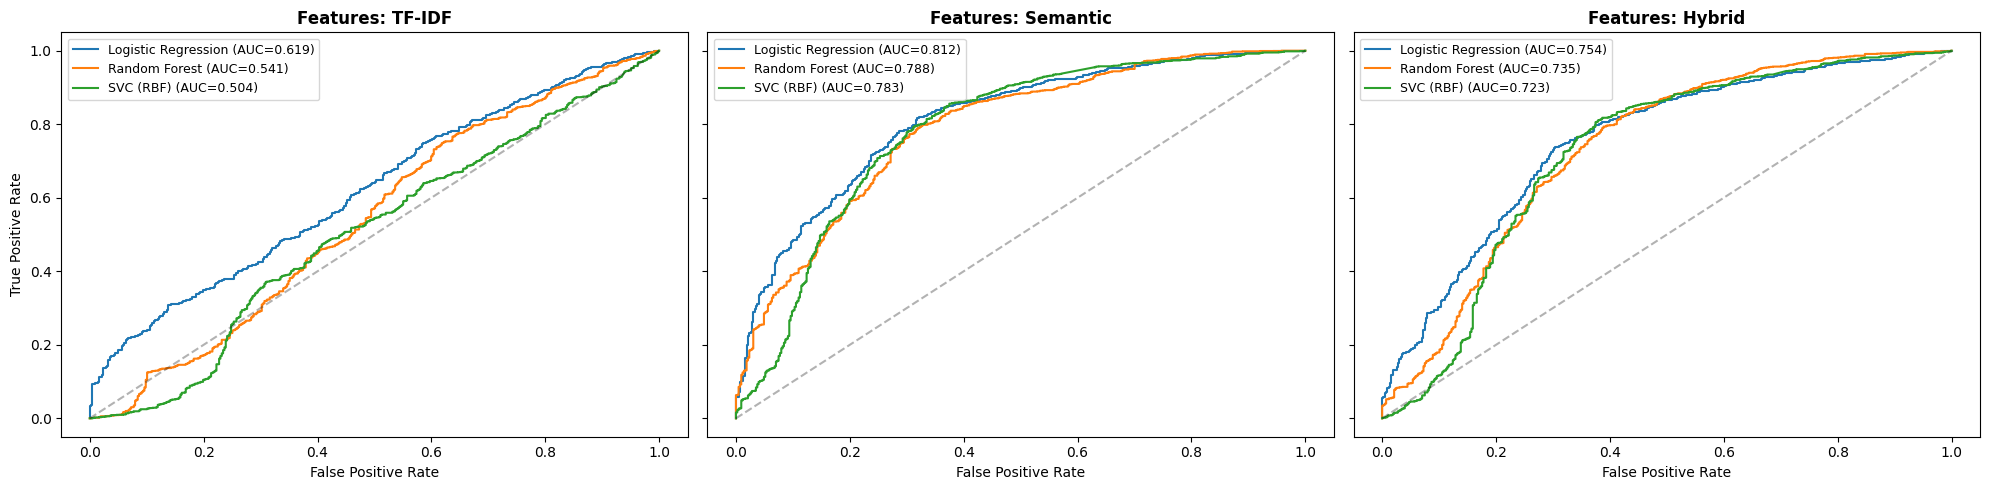

In [10]:
fig, axes = plt.subplots(1, len(feature_sets), figsize=(20, 5), sharey=True)

for ax, fname in zip(axes, feature_sets):
    for mname in models:
        fpr, tpr = roc_data[(fname, mname)]
        auc = results_df.loc[(results_df['Feature Set'] == fname) & (results_df['Model'] == mname), 'ROC-AUC'].values[0]
        ax.plot(fpr, tpr, label=f'{mname} (AUC={auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(f'Features: {fname}', fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.legend(fontsize=9)

axes[0].set_ylabel('True Positive Rate')
plt.tight_layout()
plt.show()

## Confusion matrix & classification report (best combination)

In [11]:
# Identify the exact winning combination
best = results_df.loc[results_df['F1-Score'].idxmax()]
best_fname, best_mname = best['Feature Set'], best['Model']

print(f"OVERALL BEST: {best_fname} + {best_mname} (F1: {best['F1-Score']:.4f})")


OVERALL BEST: Semantic + Logistic Regression (F1: 0.7142)


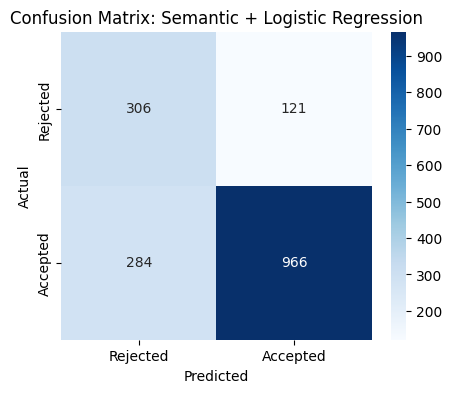

In [12]:
# Retrieve predictions properly (using '_' to ignore the model object since it's not needed here)
best_pred, best_proba, _ = fitted_artifacts[(best_fname, best_mname)]

# Plot Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, best_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Accepted'], yticklabels=['Rejected', 'Accepted'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f"Confusion Matrix: {best_fname} + {best_mname}")
plt.show()


In [13]:

# Print Classification Report
print("\nClassification Report:")
print(classification_report(y_test, best_pred, target_names=['Rejected', 'Accepted']))



Classification Report:
              precision    recall  f1-score   support

    Rejected       0.52      0.72      0.60       427
    Accepted       0.89      0.77      0.83      1250

    accuracy                           0.76      1677
   macro avg       0.70      0.74      0.71      1677
weighted avg       0.79      0.76      0.77      1677




 THRESHOLD: 0.40


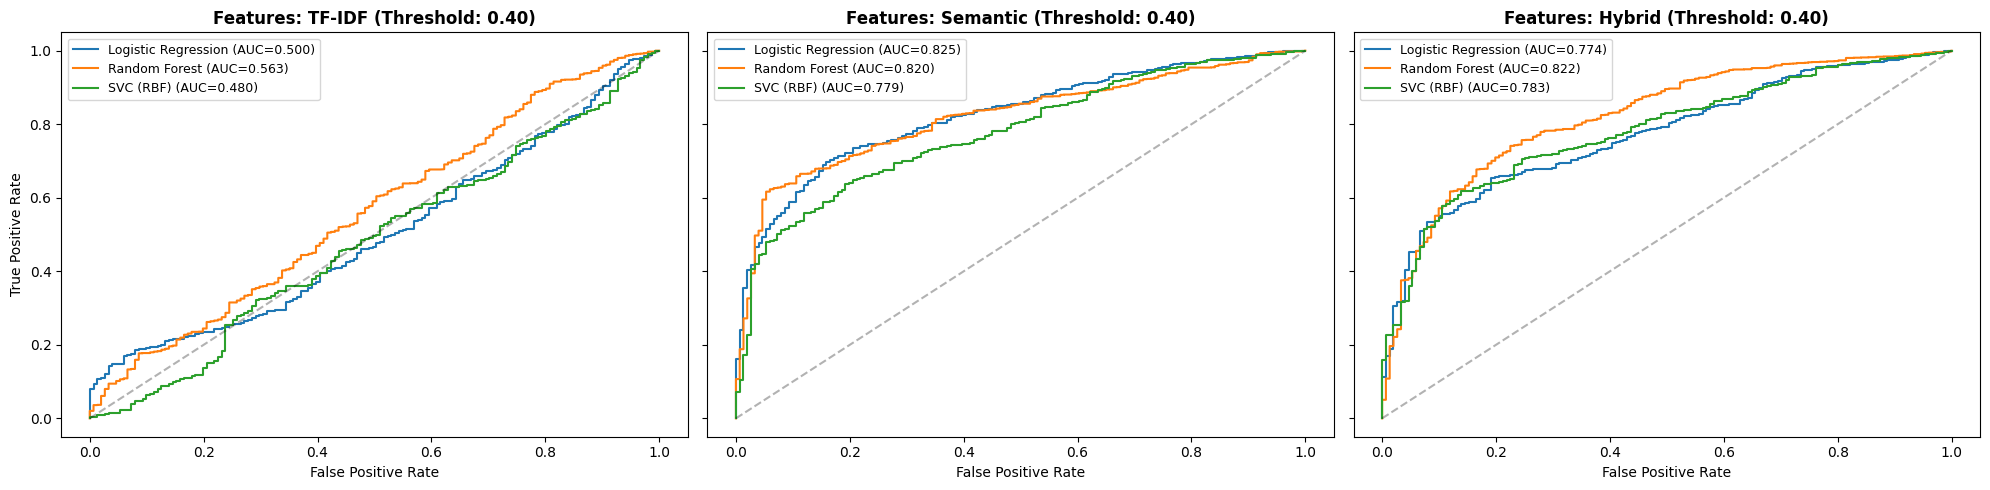

OVERALL BEST (Threshold 0.40): Hybrid + Random Forest (F1: 0.6302)


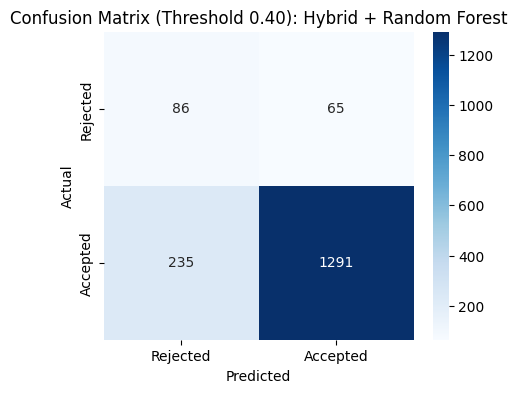


Classification Report (Threshold 0.40):
              precision    recall  f1-score   support

    Rejected       0.27      0.57      0.36       151
    Accepted       0.95      0.85      0.90      1526

    accuracy                           0.82      1677
   macro avg       0.61      0.71      0.63      1677
weighted avg       0.89      0.82      0.85      1677


 THRESHOLD: 0.45


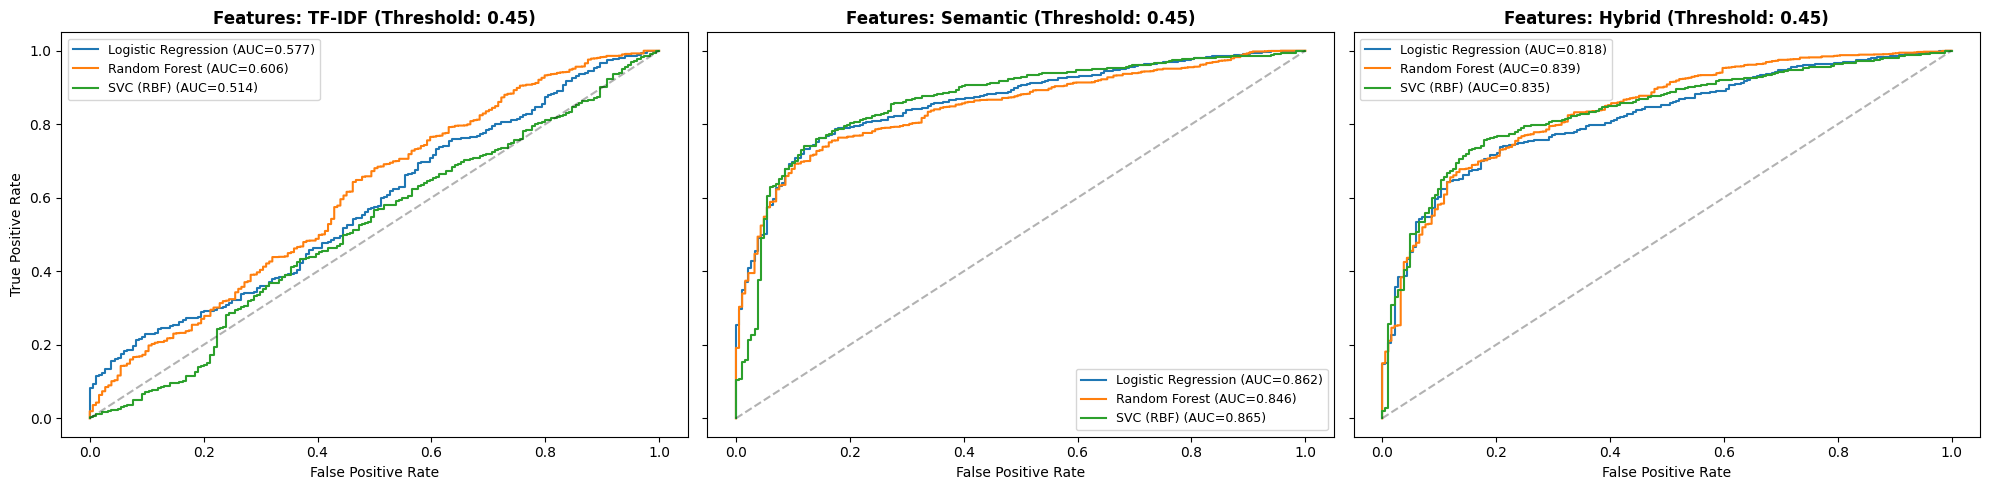

OVERALL BEST (Threshold 0.45): Semantic + Logistic Regression (F1: 0.6665)


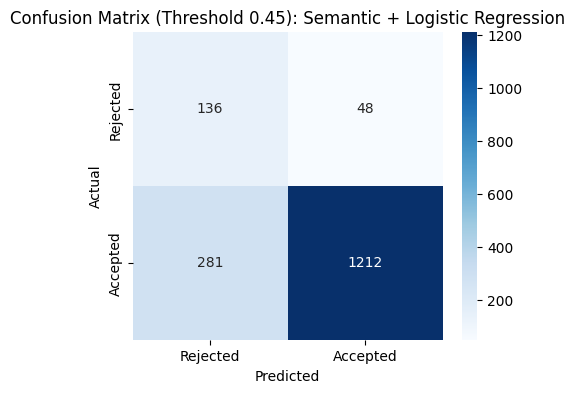


Classification Report (Threshold 0.45):
              precision    recall  f1-score   support

    Rejected       0.33      0.74      0.45       184
    Accepted       0.96      0.81      0.88      1493

    accuracy                           0.80      1677
   macro avg       0.64      0.78      0.67      1677
weighted avg       0.89      0.80      0.83      1677


 THRESHOLD: 0.50


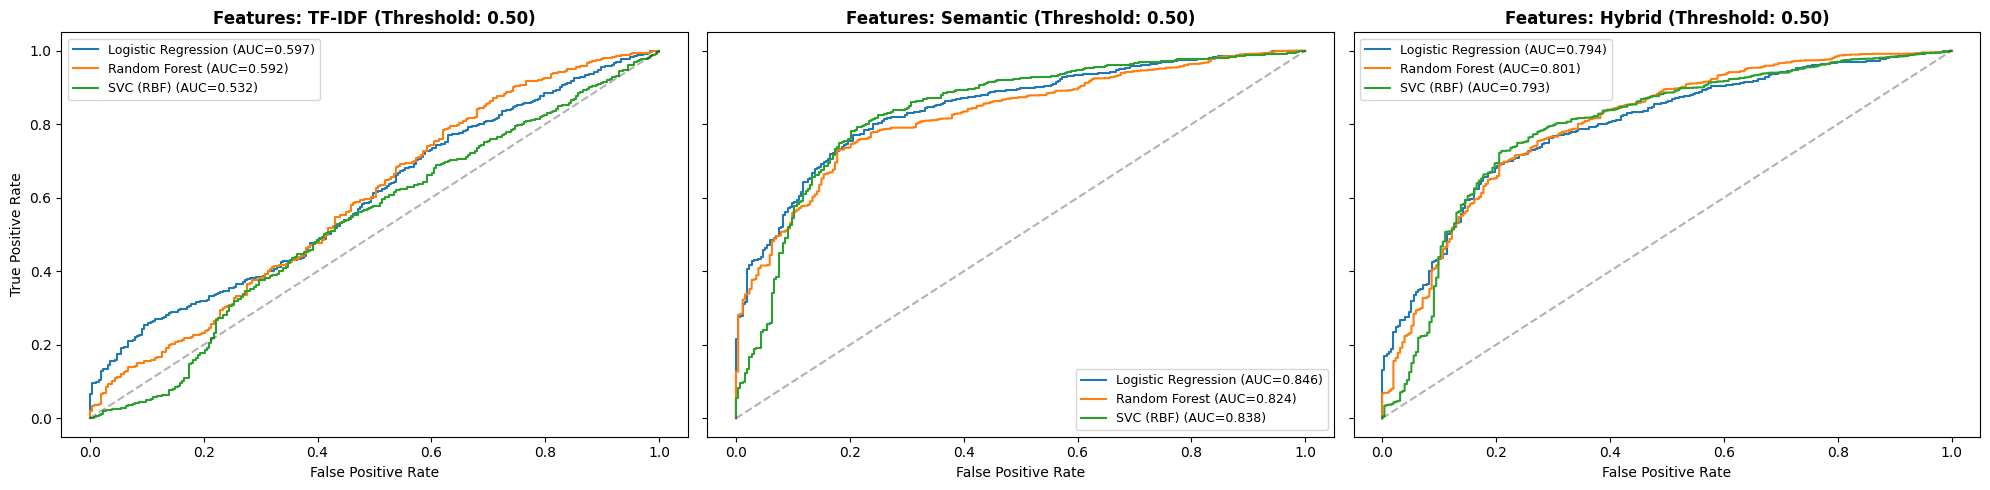

OVERALL BEST (Threshold 0.50): Semantic + Logistic Regression (F1: 0.6942)


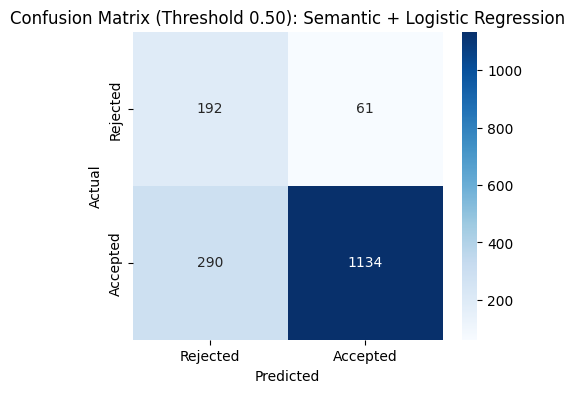


Classification Report (Threshold 0.50):
              precision    recall  f1-score   support

    Rejected       0.40      0.76      0.52       253
    Accepted       0.95      0.80      0.87      1424

    accuracy                           0.79      1677
   macro avg       0.67      0.78      0.69      1677
weighted avg       0.87      0.79      0.81      1677


 THRESHOLD: 0.55


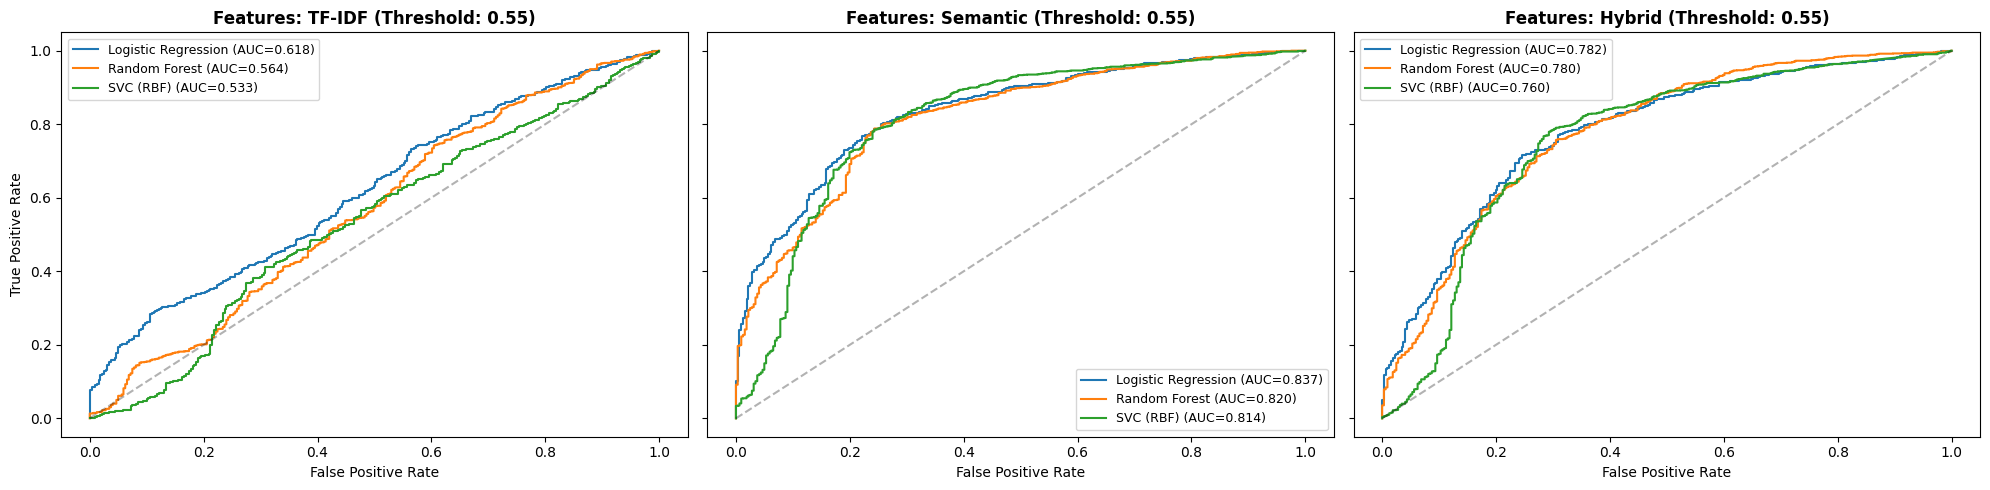

OVERALL BEST (Threshold 0.55): Semantic + Logistic Regression (F1: 0.7035)


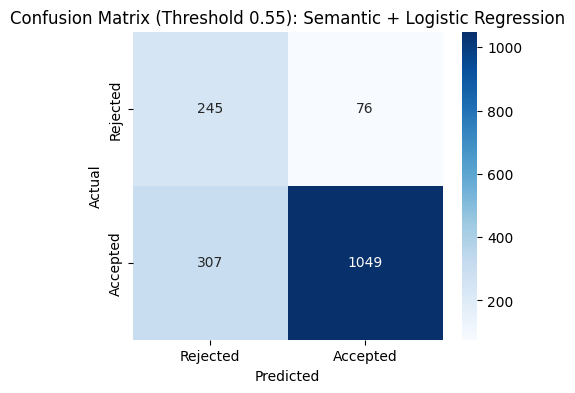


Classification Report (Threshold 0.55):
              precision    recall  f1-score   support

    Rejected       0.44      0.76      0.56       321
    Accepted       0.93      0.77      0.85      1356

    accuracy                           0.77      1677
   macro avg       0.69      0.77      0.70      1677
weighted avg       0.84      0.77      0.79      1677


 THRESHOLD: 0.60


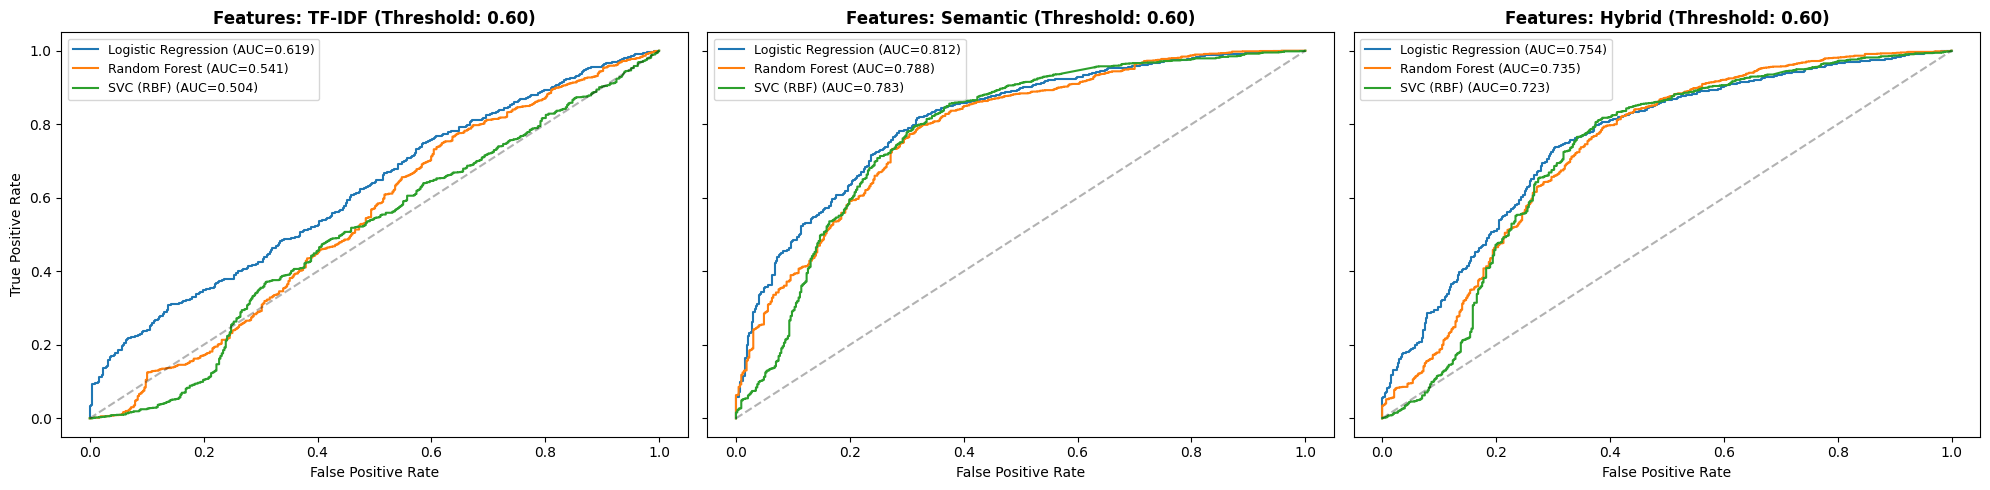

OVERALL BEST (Threshold 0.60): Semantic + Logistic Regression (F1: 0.7142)


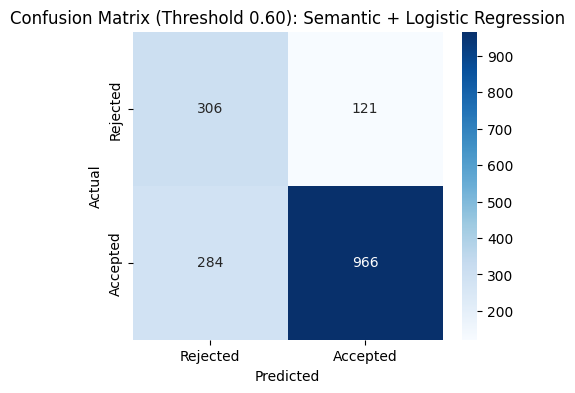


Classification Report (Threshold 0.60):
              precision    recall  f1-score   support

    Rejected       0.52      0.72      0.60       427
    Accepted       0.89      0.77      0.83      1250

    accuracy                           0.76      1677
   macro avg       0.70      0.74      0.71      1677
weighted avg       0.79      0.76      0.77      1677


 THRESHOLD: 0.65


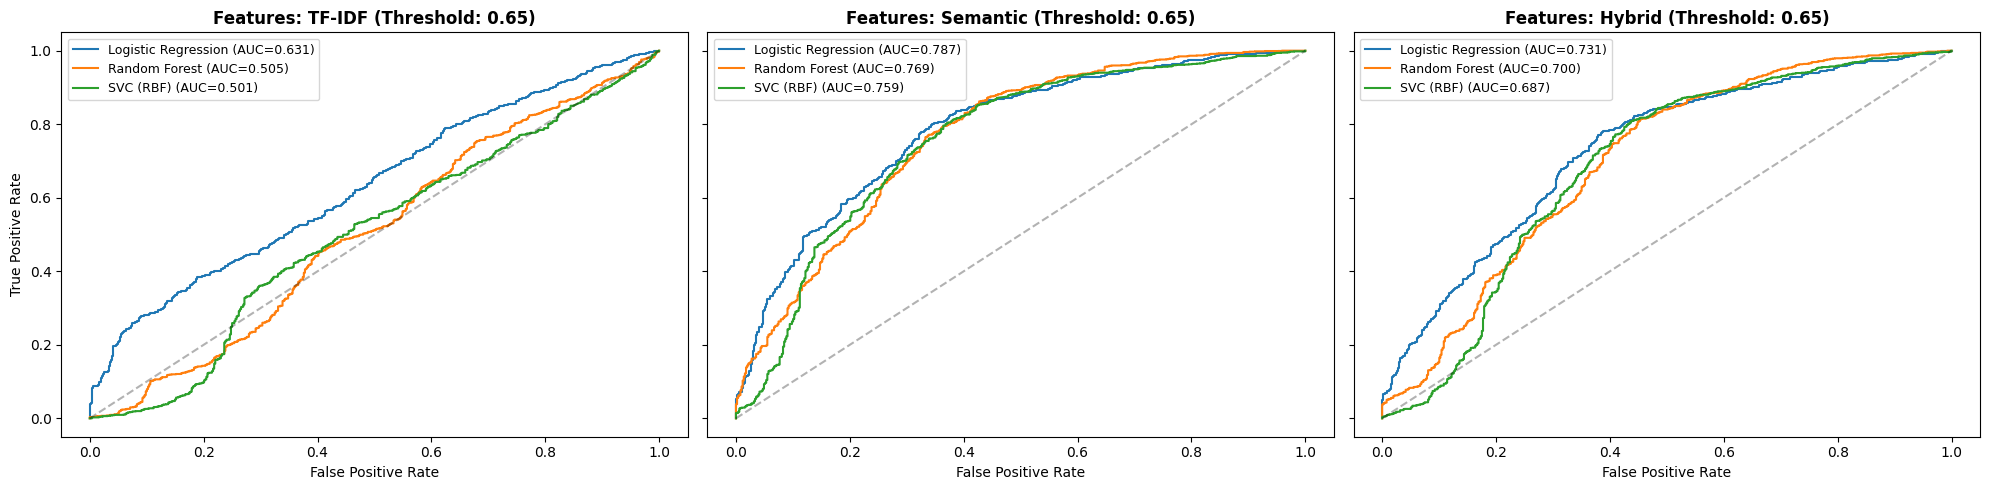

OVERALL BEST (Threshold 0.65): Semantic + Random Forest (F1: 0.7038)


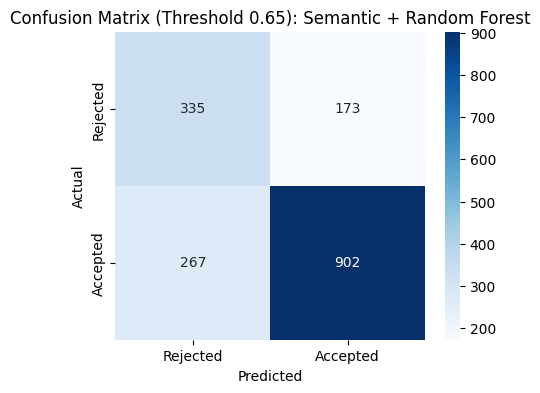


Classification Report (Threshold 0.65):
              precision    recall  f1-score   support

    Rejected       0.56      0.66      0.60       508
    Accepted       0.84      0.77      0.80      1169

    accuracy                           0.74      1677
   macro avg       0.70      0.72      0.70      1677
weighted avg       0.75      0.74      0.74      1677


 THRESHOLD: 0.70


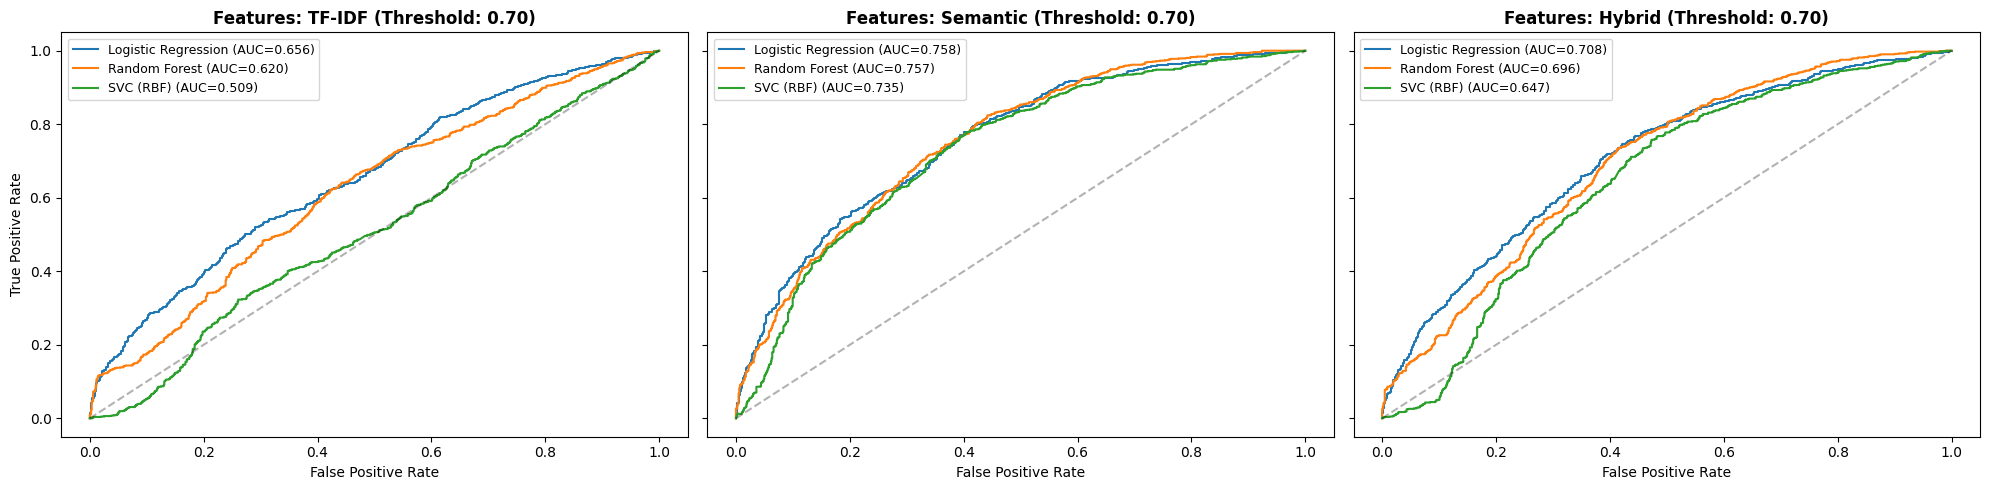

OVERALL BEST (Threshold 0.70): Semantic + Logistic Regression (F1: 0.6825)


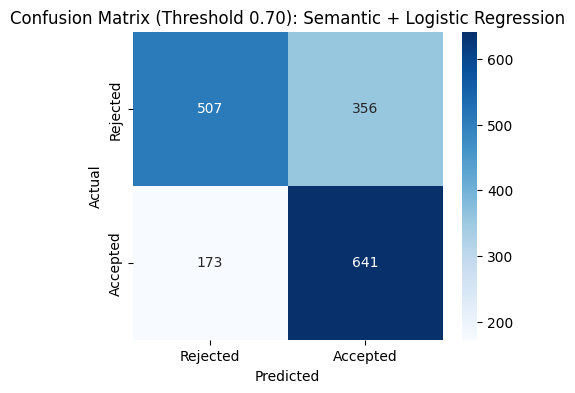


Classification Report (Threshold 0.70):
              precision    recall  f1-score   support

    Rejected       0.75      0.59      0.66       863
    Accepted       0.64      0.79      0.71       814

    accuracy                           0.68      1677
   macro avg       0.69      0.69      0.68      1677
weighted avg       0.70      0.68      0.68      1677


 THRESHOLD: 0.75


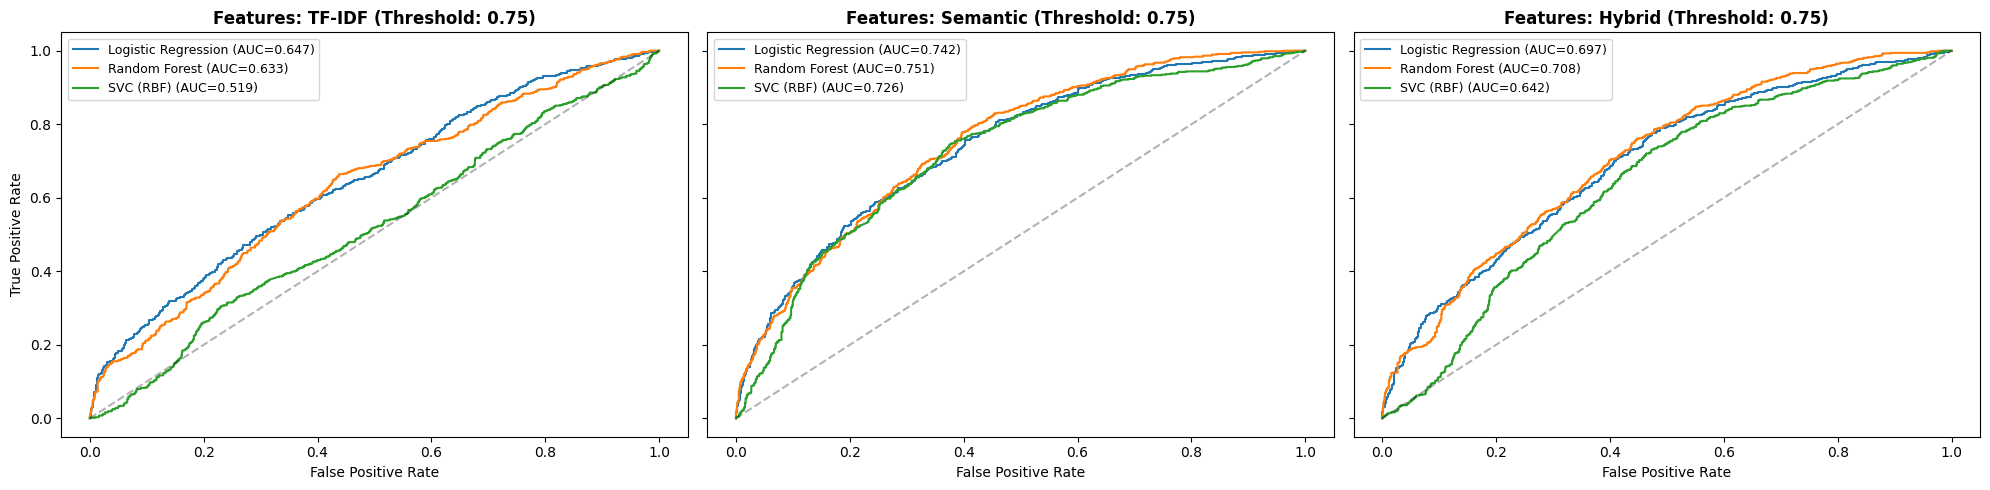

OVERALL BEST (Threshold 0.75): Semantic + Random Forest (F1: 0.6696)


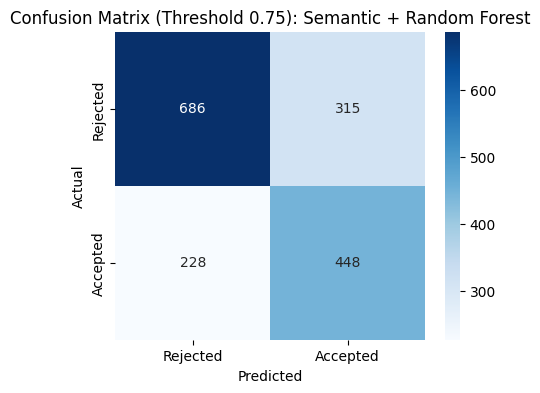


Classification Report (Threshold 0.75):
              precision    recall  f1-score   support

    Rejected       0.75      0.69      0.72      1001
    Accepted       0.59      0.66      0.62       676

    accuracy                           0.68      1677
   macro avg       0.67      0.67      0.67      1677
weighted avg       0.68      0.68      0.68      1677


 THRESHOLD: 0.80


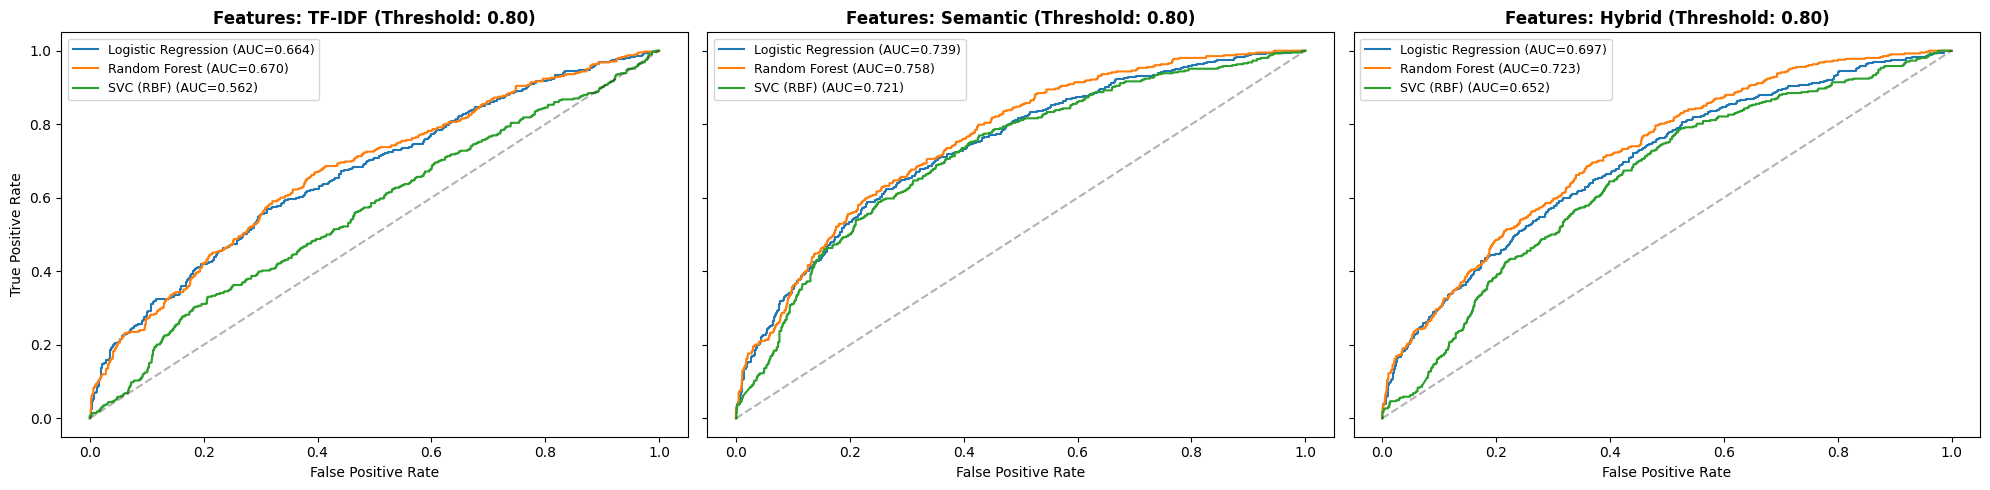

OVERALL BEST (Threshold 0.80): Semantic + Random Forest (F1: 0.6308)


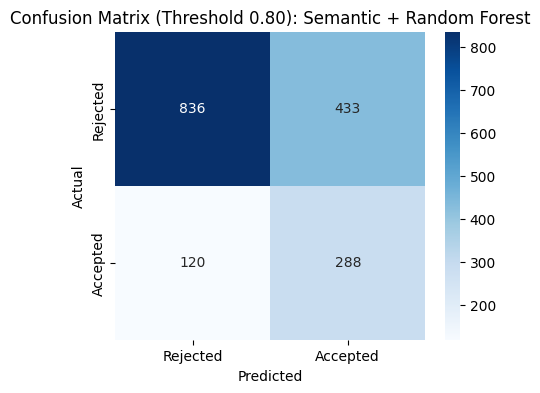


Classification Report (Threshold 0.80):
              precision    recall  f1-score   support

    Rejected       0.87      0.66      0.75      1269
    Accepted       0.40      0.71      0.51       408

    accuracy                           0.67      1677
   macro avg       0.64      0.68      0.63      1677
weighted avg       0.76      0.67      0.69      1677


 THRESHOLD: 0.85


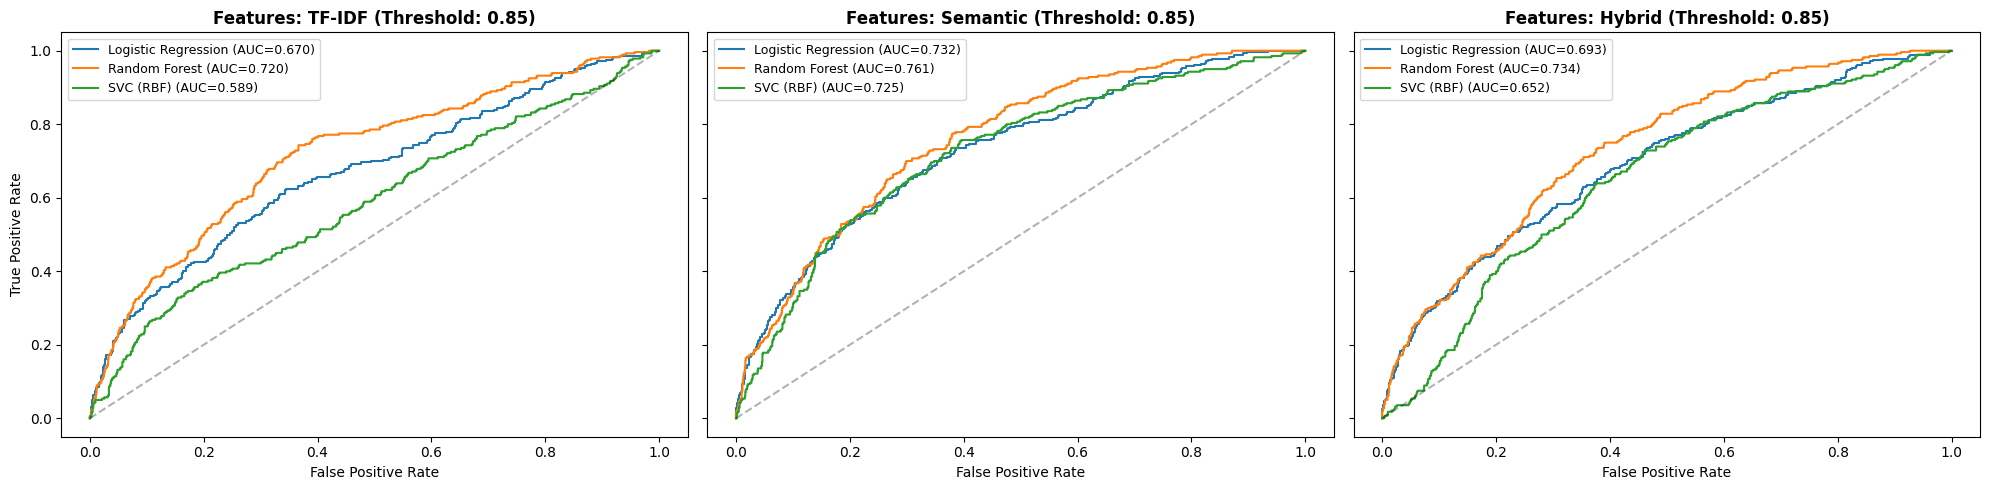

OVERALL BEST (Threshold 0.85): TF-IDF + Random Forest (F1: 0.6187)


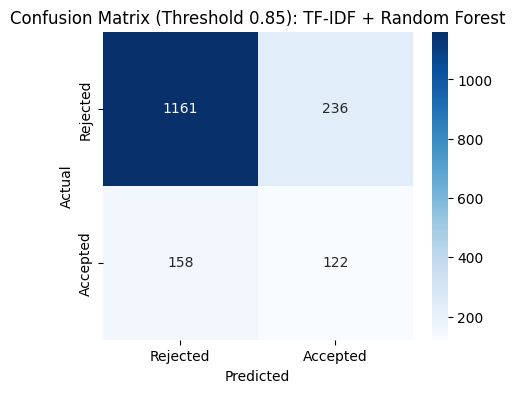


Classification Report (Threshold 0.85):
              precision    recall  f1-score   support

    Rejected       0.88      0.83      0.85      1397
    Accepted       0.34      0.44      0.38       280

    accuracy                           0.77      1677
   macro avg       0.61      0.63      0.62      1677
weighted avg       0.79      0.77      0.78      1677


 THRESHOLD: 0.90


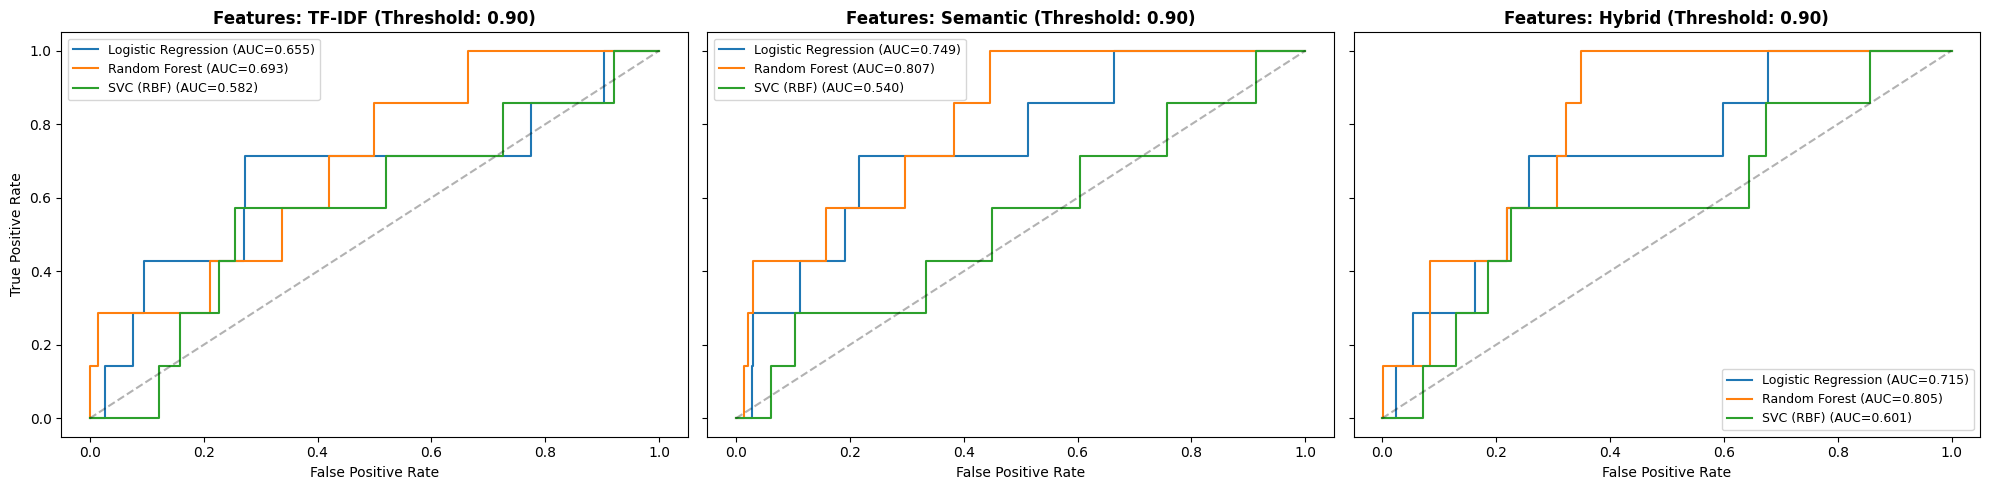

OVERALL BEST (Threshold 0.90): TF-IDF + Random Forest (F1: 0.5446)


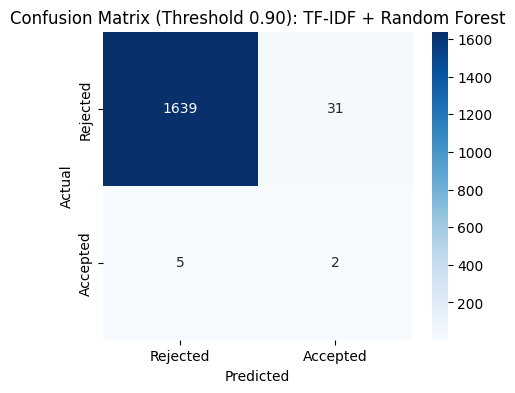


Classification Report (Threshold 0.90):
              precision    recall  f1-score   support

    Rejected       1.00      0.98      0.99      1670
    Accepted       0.06      0.29      0.10         7

    accuracy                           0.98      1677
   macro avg       0.53      0.63      0.54      1677
weighted avg       0.99      0.98      0.99      1677



In [14]:


# Loop over thresholds from 0.40 to 0.90 in steps of 0.05
for raw_threshold in range(40, 91, 5):
    threshold = raw_threshold / 100.0

    # 1. Update the target variable in the main DataFrame
    df['CV_Accepted'] = np.where(df['matched_score'] >= threshold, 1, 0)

    # 2. Re-extract train and test target arrays for the current threshold
    y_train = df.iloc[train_idx]['CV_Accepted'].values
    y_test = df.iloc[test_idx]['CV_Accepted'].values

    # Safety check: Skip if test set loses a class at extreme thresholds
    if len(np.unique(y_test)) < 2:
        print(
            f"\nSkipping Threshold {threshold:.2f}: Test set contains only"
            " one class."
        )
        continue

    results = []
    fitted_artifacts = {}
    roc_data = {}

    # 3. Model Training & Evaluation
    for fname in feature_sets.keys():
        X_train_scaled = X_train_scaled_sets[fname]
        X_test_scaled = X_test_scaled_sets[fname]

        for mname, model_template in models.items():
            model = clone(model_template)

            # Train
            model.fit(X_train_scaled, y_train)

            # Predict Classes & Probabilities
            y_pred = model.predict(X_test_scaled)
            y_proba = model.predict_proba(X_test_scaled)[:, 1]

            # Calculate Metrics
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='macro')
            auc = roc_auc_score(y_test, y_proba)

            # Calculate ROC coordinates
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            roc_data[(fname, mname)] = (fpr, tpr)

            # Store results
            results.append({
                'Feature Set': fname,
                'Model': mname,
                'Accuracy': acc,
                'F1-Score': f1,
                'ROC-AUC': auc,
            })
            fitted_artifacts[(fname, mname)] = (y_pred, y_proba, model)

    # 4. Convert results list to DataFrame BEFORE plotting & querying
    results_df = pd.DataFrame(results)

    print('\n' + '=' * 50)
    print(f' THRESHOLD: {threshold:.2f}')
    print('=' * 50)

    # 5. Plot ROC Curves
    fig, axes = plt.subplots(
        1, len(feature_sets), figsize=(20, 5), sharey=True
    )
    for ax, fname in zip(axes, feature_sets):
        for mname in models:
            fpr, tpr = roc_data[(fname, mname)]
            auc_val = results_df.loc[
                (results_df['Feature Set'] == fname)
                & (results_df['Model'] == mname),
                'ROC-AUC',
            ].values[0]
            ax.plot(fpr, tpr, label=f'{mname} (AUC={auc_val:.3f})')

        ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
        ax.set_title(
            f'Features: {fname} (Threshold: {threshold:.2f})',
            fontsize=12,
            fontweight='bold',
        )
        ax.set_xlabel('False Positive Rate')
        ax.legend(fontsize=9)

    axes[0].set_ylabel('True Positive Rate')
    plt.tight_layout()
    plt.show()

    # 6. Identify the exact winning combination
    best = results_df.loc[results_df['F1-Score'].idxmax()]
    best_fname, best_mname = best['Feature Set'], best['Model']
    print(
        f"OVERALL BEST (Threshold {threshold:.2f}): {best_fname} + {best_mname}"
        f" (F1: {best['F1-Score']:.4f})"
    )

    # Retrieve predictions
    best_pred, best_proba, _ = fitted_artifacts[(best_fname, best_mname)]

    # 7. Plot Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        confusion_matrix(y_test, best_pred),
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Rejected', 'Accepted'],
        yticklabels=['Rejected', 'Accepted'],
    )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(
        f'Confusion Matrix (Threshold {threshold:.2f}): {best_fname} +'
        f' {best_mname}'
    )
    plt.show()

    # 8. Print Classification Report
    print(f'\nClassification Report (Threshold {threshold:.2f}):')
    print(
        classification_report(
            y_test, best_pred, target_names=['Rejected', 'Accepted']
        )
    )